# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** Jonah Watson
**Date:** March 23, 2026

---

## Setup: Install and Load Libraries

In [1]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [3]:


# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


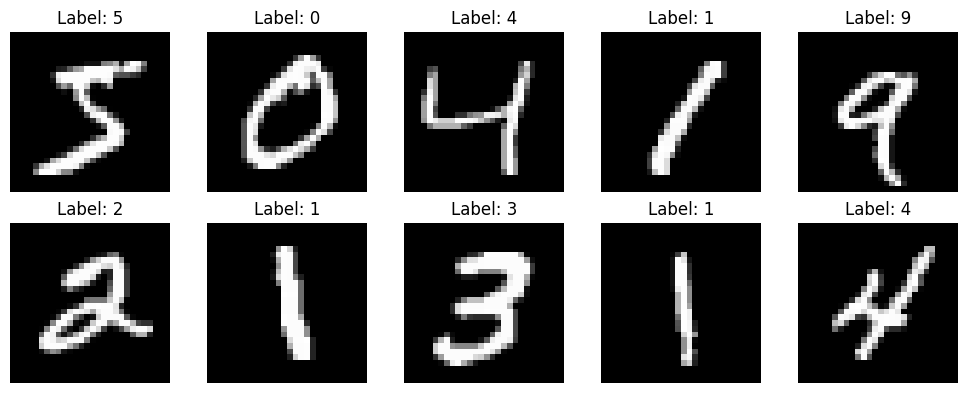

In [4]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [5]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [9]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')

])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Display model architecture
baseline_cnn.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9758 - loss: 0.0784 - val_accuracy: 0.9858 - val_loss: 0.0506
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9865 - val_loss: 0.0430
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9899 - loss: 0.0314 - val_accuracy: 0.9893 - val_loss: 0.0359
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9920 - val_loss: 0.0324
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9915 - val_loss: 0.0332

BASELINE CNN RESULTS
Final Training Accuracy: 0.9941
Final Validation Accuracy: 0.9915
Test Accuracy: 0.9837
Training Time: 49.91 seconds


---
## Step 3: Experiment with Filter Counts

In [14]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline
# Record training time
print("\nTraining CNN with fewer filters (16, 32)...")
start_time = time.time()

fewer_filters_cnn = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Build, compile, and train model
fewer_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    
)

history_fewer = baseline_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

fewer_time = time.time() - start_time

fewer_test_loss, fewer_test_acc = fewer_filters_cnn.evaluate(X_test, y_test, verbose=0)

# Display model architecture
# Record validation accuracy

print("\n" + "="*80)
print("FEWER FILTERS CNN RESULTS (16, 32)")
print("="*80)
print(f"Final Training Accuracy: {history_fewer.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_fewer.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {fewer_test_acc:.4f}")
print(f"Training Time: {fewer_time:.2f} seconds")
print("="*80)


Training CNN with fewer filters (16, 32)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9953 - loss: 0.0136 - val_accuracy: 0.9905 - val_loss: 0.0320
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9908 - val_loss: 0.0396
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9961 - loss: 0.0104 - val_accuracy: 0.9925 - val_loss: 0.0338
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9976 - loss: 0.0069 - val_accuracy: 0.9920 - val_loss: 0.0407
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9981 - loss: 0.0058 - val_accuracy: 0.9908 - val_loss: 0.0435

FEWER FILTERS CNN RESULTS (16, 32)
Final Training Accuracy: 0.9981
Final Validation Accuracy: 0.9908
Test Accuracy: 0.1038
Training Time: 52.09 seconds


In [15]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
print("\nTraining CNN with more filters (64, 128)...")
start_time = time.time()

more_filters_cnn = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Build, compile, and train model
more_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    
)

history_more = baseline_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

more_time = time.time() - start_time

# Record validation accuracy
more_test_loss, more_test_acc = more_filters_cnn.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*80)
print("MORE FILTERS CNN RESULTS (64, 128)")
print("="*80)
print(f"Final Training Accuracy: {history_more.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_more.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {more_test_acc:.4f}")
print(f"Training Time: {more_time:.2f} seconds")
print("="*80)



Training CNN with more filters (64, 128)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9918 - val_loss: 0.0451
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9902 - val_loss: 0.0541
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.9905 - val_loss: 0.0425
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9900 - val_loss: 0.0605
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 0.9888 - val_loss: 0.0819

MORE FILTERS CNN RESULTS (64, 128)
Final Training Accuracy: 0.9991
Final Validation Accuracy: 0.9888
Test Accuracy: 0.1051
Training Time: 49.07 seconds


### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

I had the highest training accuracy with "more" filters (0.9991), followed by "fewer" filters (0.9981), and lastly a "middle" number of filters at (0.9941).
My validation accuracy, however, moved from most to least desirable opposite of training accuracy.
To be honest, there was very little difference in any of these values.
If you go crazy on adding layers, it seems you may experience worse final validation accuracy.
If you go extremely light on layers, however, it seems you may experience worse final training accuracy.

---
## Step 4: Experiment with Kernel Sizes

In [18]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
print("\nTraining CNN with 5x5 kernels...")
start_time = time.time()

medium_kernels_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Build, compile, and train model
medium_kernels_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_medium = medium_kernels_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

medium_time = time.time() - start_time

# Record validation accuracy
medium_test_loss, medium_test_acc = medium_kernels_cnn.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*80)
print("MEDIUM KERNEL CNN RESULTS (5x5, 5x5)")
print("="*80)
print(f"Final Training Accuracy: {history_medium.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_medium.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {medium_test_acc:.4f}")
print(f"Training Time: {medium_time:.2f} seconds")
print("="*80)



Training CNN with 5x5 kernels...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9509 - loss: 0.1618 - val_accuracy: 0.9882 - val_loss: 0.0443
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9864 - loss: 0.0453 - val_accuracy: 0.9887 - val_loss: 0.0413
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9896 - loss: 0.0318 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9903 - val_loss: 0.0311
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9893 - val_loss: 0.0383

MEDIUM KERNEL CNN RESULTS (5x5, 5x5)
Final Training Accuracy: 0.9941
Final Validation Accuracy: 0.9893
Test Accuracy: 0.9894
Training Time: 66.15 seconds


In [21]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
print("\nTraining CNN with mixed kernels...")
start_time = time.time()

mixed_kernels_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Build, compile, and train model
mixed_kernels_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mixed = mixed_kernels_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

mixed_time = time.time() - start_time

# Record validation accuracy
mixed_test_loss, mixed_test_acc = mixed_kernels_cnn.evaluate(X_test, y_test, verbose=0)

# TODO: Build, compile, and train model
# Record validation accuracy
print("\n" + "="*80)
print("MIXED KERNEL CNN RESULTS (5x5, 3x3)")
print("="*80)
print(f"Final Training Accuracy: {history_mixed.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_mixed.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {mixed_test_acc:.4f}")
print(f"Training Time: {mixed_time:.2f} seconds")
print("="*80)




Training CNN with mixed kernels...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9499 - loss: 0.1655 - val_accuracy: 0.9868 - val_loss: 0.0441
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9850 - loss: 0.0479 - val_accuracy: 0.9892 - val_loss: 0.0398
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9898 - loss: 0.0326 - val_accuracy: 0.9882 - val_loss: 0.0407
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9921 - loss: 0.0238 - val_accuracy: 0.9882 - val_loss: 0.0427
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9942 - loss: 0.0179 - val_accuracy: 0.9917 - val_loss: 0.0305

MIXED KERNEL CNN RESULTS (5x5, 3x3)
Final Training Accuracy: 0.9942
Final Validation Accuracy: 0.9917
Test Accuracy: 0.9927
Training Time: 45.87 seconds


### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Kernel size affects what the network learns by allowing the user to choose if they want to focus on capturing fine details like (1x1) or cover larger areas (like 5x5). 
I tried running 5x5 on both layers and also tried running 5x5 on one layer and 3x3 on the other.
The version with both a 5x5 and a 3x3 ran slightly better, but again, there was very little difference.
Having two different kernel sizes, and more specificly one of smaller size, allows for more details to be captured, in this case

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [22]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split
print("Training best CNN architecture...")
start_time = time.time()

# TODO: Build, compile, and train your best model
best_cnn = keras.Sequential([
    layers.Conv2D(64, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

# Store the training history
best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_best = best_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
)

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(X_test, y_test, verbose=0)

# TODO: Build, compile, and train model
# Record validation accuracy
print("\n" + "="*80)
print("BEST CNN RESULTS (5x5, 3x3)")
print("="*80)
print(f"Final Training Accuracy: {history_best.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_best.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_time:.2f} seconds")
print("="*80)

Training best CNN architecture...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9537 - loss: 0.1479 - val_accuracy: 0.9857 - val_loss: 0.0467
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9861 - loss: 0.0442 - val_accuracy: 0.9887 - val_loss: 0.0415
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.9867 - val_loss: 0.0445
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9930 - loss: 0.0212 - val_accuracy: 0.9900 - val_loss: 0.0335
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9890 - val_loss: 0.0363
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.9954 - loss: 0.0135 - val_accuracy: 0.9899 - val_loss: 0.0374
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9962 - loss: 0.0105 - val_accuracy: 0.9912 - val_loss: 0.0362
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9973 - loss: 0.0082 - 

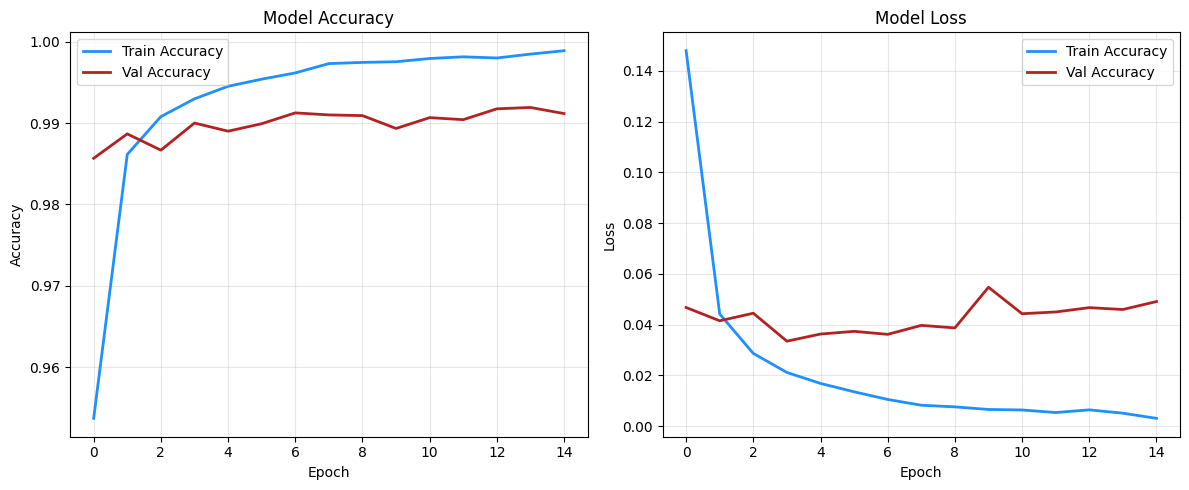

In [24]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Train Accuracy', color='dodgerblue', lw=2)
plt.plot(history_best.history['val_accuracy'], label='Val Accuracy', color='firebrick', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(history_best.history['loss'], label='Train Accuracy', color='dodgerblue', lw=2)
plt.plot(history_best.history['val_loss'], label='Val Accuracy', color='firebrick', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [25]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [26]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feedforward_nn.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
history_ff = feedforward_nn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*80)
print("FEEDFORWARD NETWORK RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history_ff.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_ff.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {ff_test_acc:.4f}")
print(f"Training Time: {feedforward_time:.2f} seconds")
print("="*80)



Training feedforward network...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9106 - loss: 0.3080 - val_accuracy: 0.9521 - val_loss: 0.1614
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9619 - loss: 0.1268 - val_accuracy: 0.9669 - val_loss: 0.1160
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9737 - loss: 0.0872 - val_accuracy: 0.9706 - val_loss: 0.0969
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0638 - val_accuracy: 0.9740 - val_loss: 0.0886
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9835 - loss: 0.0513 - val_accuracy: 0.9708 - val_loss: 0.0923
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9877 - loss: 0.0386 - val_accuracy: 0.9732 - val_loss: 0.0937
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9895 - loss: 0.0332 - val_accuracy: 0.9727 - val_loss: 0.0970
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9914 -

In [29]:
# TODO: Create comparison table
comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        '32/64 filters, 3x3 kernels', 
        '64/128 filters, 5x5/3x3 mixed', 
        'Dense 128/64 nodes'
    ],
    'Test Accuracy': [
        f"{baseline_test_acc:.4f}", 
        f"{best_test_acc:.4f}", 
        f"{ff_test_acc:.4f}"
    ],
    'Training Time (s)': [
        f"{baseline_time:.2f}", 
        f"{best_time:.2f}", 
        f"{feedforward_time:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                  Architecture Test Accuracy Training Time (s)
  Baseline CNN    32/64 filters, 3x3 kernels        0.9837             49.91
      Best CNN 64/128 filters, 5x5/3x3 mixed        0.9923            334.87
Feedforward NN            Dense 128/64 nodes        0.9747             11.38


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The feedforward network performed worse on image data than both my baseline CNN and best CNN.
CNN's spatial awareness allows it to use the spacial context to its advantage, whereas with a feedforward model, edges and shapes are often harder to make out.


---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

I can't really see CNNs and RNNs helping with my final project very much. 
My data is tabular and keeps track of details on certan properties in Miami, and so I will choose to use ML models such as Random Forest, which excel with tabular data. Random Forest would likely struggle with images just as CNNs would struggle with tabular data.
My data is mostly descriptive of properties... of properties, and doesn't show data month by month, or in any way like that.
Perhaps I could find a way to integrate CNNs with predictive modeling, but it seems that it would make more sense to just stick with traditional ML models for what I'm working with.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.